# DeepOnet-Grid

本工作构建了一个高效的网络DeepONet-Grid，用于对故障后的电力系统进行动态安全分析，该网络

`
(i) 接收故障前和故障期间收集的轨迹作为输入，并且
(ii) 输出预测的故障后轨迹。
`

此外，本网络还通过不确定性量化（Uncertainty Quantification）为其方法赋予了在效率与可靠/可信预测之间取得平衡的能力。

原始论文：[DeepONet-grid-UQ: A trustworthy deep operator framework for predicting the power grid’s post-fault trajectories](!https://www.sciencedirect.com/science/article/abs/pii/S0925231223002503)


## 研究背景与动机

电力系统作为关键基础设施，其稳定性和可靠性对现代社会至关重要。然而，电网经常面临罕见但严重的故障和扰动，这些事件可能导致系统不稳定，甚至引发大规模停电。

传统的动态安全分析需要求解复杂的非线性微分代数方程组，计算成本极高，难以实现实时分析。随着电网的转型，电力公司迫切需要能够进行近实时的动态安全评估。

现有的机器学习方法主要关注二分类问题（稳定/不稳定），缺乏对故障后轨迹的定量预测能力。系统运营商和规划者需要了解故障后各种状态变量的轨迹，以评估电压或频率是否会违反预定义限制并触发负荷切除等保护措施。

### 方法细节

#### 工作原理

DeepONet-Grid-UQ基于深度算子网络（Deep Operator Network）理论，其核心思想是将电力系统故障后的动态行为建模为一个算子映射问题：

- **输入函数空间**：故障前和故障期间的轨迹数据 u(t) ∈ U
- **输出函数空间**：故障后预测轨迹 y(t) ∈ Y
- **算子映射**：G: U → Y

该网络学习从输入轨迹到输出轨迹的非线性映射关系，即：
y(t) = G[u](t)

#### 网络架构设计

图1： 网络结构图
![网络架构图](images/arch.png)
DeepONet采用分支-主干（Branch-Trunk）架构：

**分支网络（Branch Network）**：

- 输入：故障前和故障期间的轨迹序列 u(t₁), u(t₂), ..., u(tₙ)
- 功能：提取输入轨迹的特征表示
- 输出：特征向量 b ∈ ℝᵖ

**主干网络（Trunk Network）**：

- 输入：时间点 t
- 功能：学习时间基函数
- 输出：时间特征向量 τ(t) ∈ ℝᵖ

**输出计算**：

G[u](t) = ⟨b, τ(t)⟩ = Σᵢ₌₁ᵖ bᵢτᵢ(t)

其中 ⟨·,·⟩ 表示内积运算。

#### 不确定性量化方法

原始工作介绍了两种不确定性量化方法，本工作只实现了概率DeepONet（Prob-DeepONet）不确定性量化方法：

**1. 贝叶斯DeepONet (B-DeepONet)**：

- 使用随机梯度哈密顿蒙特卡洛（SGHMC）采样
- 从网络参数的后验分布中采样：θ ∼ p(θ|D)
- 预测不确定性通过多次前向传播获得：

y(t) = ∫ G[u](t; θ) p(θ|D) dθ

**2. 概率DeepONet (Prob-DeepONet)**：

- 网络同时输出预测均值 μ(t) 和预测标准差 σ(t)
- 假设输出服从高斯分布：y(t) ∼ N(μ(t), σ²(t))
- 损失函数采用负对数似然：

L = -log p(y|μ, σ) = -log N(y; μ, σ²)

实践前，确保已经正确安装最新版本的MindSpore。

DeepOnet-grid实现分为以下6个步骤：

1. 配置网络与训练参数
2. 数据集加载
3. 模型构建
4. 模型训练
5. 结果可视化
6. 模型推理

In [ ]:
import os
import numpy as np
import mindspore as ms
from mindspore import context
from src.model import ProbDeepONet
from src.data import load_real_data, prepare_deeponet_data, split_data, create_datasets, trajectory_prediction
from src.metrics import MetricsCalculator
from src.trainer import create_trainer
from src.utils import plot_pred_uq

In [3]:
# ===================================
# Configuration Parameters
# ===================================
print("=" * 50)
print("DeepONet-Grid-UQ MindSpore Configuration")
print("=" * 50)

# General Parameters
verbose = True # Whether to output detailed information
seed = 1234

# DeepONet parameters (based on your data)
m = 33                    # Number of sensors (voltage data)
q = 100                   # Number of time points
n_basis = 100             # Number of basis functions
branch_type = "modified"  # Branch network type
trunk_type = "modified"   # Trunk network type
width = 200               # Network width
depth = 3                 # Network depth
activation = "sin"        # Activation function

# Training parameters
learning_rate = 5e-5      # Learning rate
batch_size = 1024           # Batch size
n_epochs = 1            # Number of epochs (for demo)

# Learning scheduler
scheduler = "cosine"
min_lr = 1e-7             # Minimum learning rate
max_lr = 1e-3             # Maximum learning rate
total_step = 10000        # Total number of steps
step_per_epoch = 1000     # Number of steps per epoch
decay_epoch = 10        # Number of epochs for decay
loss_type = "nll"         # Loss function type: "nll" (negative log likelihood)
optimizer = "adam"        # Optimizer
weight_decay = 0.0        # Weight decay
amp_level = "O0"          # Mixed precision level: "O0", "O1", "O2"

print(f"Configuration:")
print(f"  Sensors (m): {m}")
print(f"  Time points (q): {q}")
print(f"  Basis functions: {n_basis}")
print(f"  Network width: {width}")
print(f"  Network depth: {depth}")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {n_epochs}")


DeepONet-Grid-UQ MindSpore Configuration
Configuration:
  Sensors (m): 33
  Time points (q): 100
  Basis functions: 100
  Network width: 200
  Network depth: 3
  Learning rate: 5e-05
  Batch size: 1024
  Epochs: 1


In [5]:
print("\n" + "=" * 50)
print("Setting up MindSpore device and context")
print("=" * 50)

# Set random seed
np.random.seed(seed)
ms.set_seed(seed)

# Set up device context
context.set_context(mode=context.PYNATIVE_MODE, device_target="Ascend")


Setting up MindSpore device and context


In [10]:
# ===================================
# Load training and test data
# ===================================
print("\n" + "=" * 50)
print("Loading training and test data")
print("=" * 50)

# Define data paths
train_path = f"data/trustworthydatasetv2/train-data-voltage-m-33-Q-100-mix.npz"
test_path = f"data/trustworthydatasetv2/test-data-voltage-m-33-mix.npz"

# Check if files exist
if not os.path.exists(train_path):
    print(f"Training data not found: {train_path}")
    print("Please check the data path or use synthetic data")

if not os.path.exists(test_path):
    print(f"Test data not found: {test_path}")
    print("Please check the data path")

# Load training data
print(f"Loading training data from: {train_path}")
u_train, y_train, s_train = load_real_data(train_path)
print(f"Training data shapes: u={u_train.shape}, y={y_train.shape}, s={s_train.shape}")

# Load test data
print(f"Loading test data from: {test_path}")
u_test, y_test, s_test = load_real_data(test_path)
print(f"Test data shapes: u={u_test.shape}, y={y_test.shape}, s={s_test.shape}")



Loading training and test data
Loading training data from: data/trustworthydatasetv2/train-data-voltage-m-33-Q-100-mix.npz
Training data shapes: u=(77069, 33), y=(77069, 100), s=(77069, 100)
Loading test data from: data/trustworthydatasetv2/test-data-voltage-m-33-mix.npz
Test data shapes: u=(8564, 33), y=(8564, 100), s=(8564, 100)


In [ ]:
# ===================================
#  Prepare data for DeepONet
# ===================================
print("\n" + "=" * 50)
print("Preparing data for DeepONet training")
print("=" * 50)

# Prepare training data (expand multi-time-point to single query points)
print("Preparing training data...")
u_train_expanded, y_train_expanded, s_train_expanded, train_metadata = prepare_deeponet_data(u_train, y_train, s_train)
print(f"Expanded training data: u={u_train_expanded.shape}, y={y_train_expanded.shape}, s={s_train_expanded.shape}")

# Prepare test data
print("Preparing test data...")
u_test_expanded, y_test_expanded, s_test_expanded, test_metadata = prepare_deeponet_data(u_test, y_test, s_test)
print(f"Expanded test data: u={u_test_expanded.shape}, y={y_test_expanded.shape}, s={s_test_expanded.shape}")


# Split data, only use 10% of data for training for demo
print("Splitting data...")
data_splits = split_data(
    u_train_expanded, y_train_expanded, s_train_expanded,
    train_ratio=0.1, val_ratio=0.5, test_ratio=0.4
)

# Create MindSpore datasets
print("Creating MindSpore datasets...")
datasets = create_datasets(data_splits, batch_size=batch_size)
print(f"Created datasets: {list(datasets.keys())}")


Preparing data for DeepONet training
Preparing training data...
Expanded training data: u=(7706900, 33), y=(7706900, 1), s=(7706900, 1)
Preparing test data...
Expanded test data: u=(856400, 33), y=(856400, 1), s=(856400, 1)
Splitting data...
Creating MindSpore datasets...
Created datasets: ['train', 'val', 'test']


In [ ]:
# ===================================
# Build Probabilistic DeepONet
# ===================================
print("\n" + "=" * 50)
print("Building Probabilistic DeepONet model")
print("=" * 50)

# Model configuration
dim = 1  # Trunk input dimension (always 1 for DeepONet)

# Branch configuration
branch_config = {
    "type": branch_type,
    "layer_size": [m] + [width] * depth + [n_basis],  # [input] + [width] * depth + [output]
    "activation": activation
}

# Trunk configuration
trunk_config = {
    "type": trunk_type,
    "layer_size": [dim] + [width] * depth + [n_basis],  # [input] + [width] * depth + [output]
    "activation": activation
}

# Create model
model = ProbDeepONet(branch_config, trunk_config, use_bias=True)

print(f"Model created successfully")
print(f"Branch network: {branch_config['layer_size']}")
print(f"Trunk network: {trunk_config['layer_size']}")



Building Probabilistic DeepONet model
Model created successfully
Branch network: [33, 200, 200, 200, 100]
Trunk network: [1, 200, 200, 200, 100]


In [ ]:
# ===================================
# Create trainer and training configuration
# ===================================
print("\n" + "=" * 50)
print("Creating trainer and training configuration")
print("=" * 50)

# Training configuration
config = {
    'model': {
        'm': m,
        'dim': dim,
        'width': width,
        'depth': depth,
        'n_basis': n_basis,
        'branch_type': branch_type,
        'trunk_type': trunk_type,
        'activation': activation,
        'use_bias': True
    },
    'training': {
        'batch_size': batch_size,
        'epochs': n_epochs,
        'log_interval': 100,
        'eval_interval': 1000,
        'scheduler': scheduler,
        'min_lr': min_lr,
        'max_lr': max_lr,
        'total_step': total_step,
        'step_per_epoch': step_per_epoch,
        'decay_epoch': decay_epoch,
        'verbose': verbose,
        'loss_type': 'nll',
        'optimizer': 'adam',
        'weight_decay': 0.0
    },
    'output': {
        'save_dir': 'outputs',
        'save_best': True
    }
}

# Create trainer
trainer = create_trainer(model, config, save_dir='outputs', distributed=0)
print(f"Trainer created successfully")


Creating trainer and training configuration
Trainer created successfully


In [36]:
# ===================================
# Initial test (before training)
# ===================================
print("\n" + "=" * 50)
print("Initial test (before training)")
print("=" * 50)

# Test on a small subset
n_test_samples = 10
print(f"Testing on {n_test_samples} samples...")

# Get a small batch for testing
test_batch = next(datasets['test'].create_dict_iterator())
u_test_batch, y_test_batch, s_test_batch = test_batch['u'], test_batch['y'], test_batch['s']

# Forward pass
mean_pred, log_std_pred = model(u_test_batch, y_test_batch)
print(f"Initial test - Mean prediction shape: {mean_pred.shape}")
print(f"Initial test - Log std prediction shape: {log_std_pred.shape}")


Initial test (before training)
Testing on 10 samples...
Initial test - Mean prediction shape: (1024, 1)
Initial test - Log std prediction shape: (1024, 1)


In [12]:
# ===================================
# Training
# ===================================
print("\n" + "=" * 50)
print("Starting training")
print("=" * 50)

# Train the model
history = trainer.train(
    train_dataset=datasets['train'],
    val_dataset=datasets['val']
)

print("Training completed!")

***** Probabilistic Training for 100 epochs *****




Starting training


Epoch 1/100:  Train-Loss: 0.304765 Best-Loss: inf 
Epoch 2/100:  Train-Loss: -0.038343 Best-Loss: -0.128458 
Epoch 3/100:  Train-Loss: -0.143670 Best-Loss: -0.128458 
Epoch 4/100:  Train-Loss: 0.264705 Best-Loss: -0.176884 
Epoch 5/100:  Train-Loss: -0.220248 Best-Loss: -0.176884 
...
Epoch 97/100:  Train-Loss: -0.482196 Best-Loss: -0.482104 
Epoch 98/100:  Train-Loss: -0.482205 Best-Loss: -0.482124 
Epoch 99/100:  Train-Loss: -0.482214 Best-Loss: -0.482124 
Epoch 100/100:  Train-Loss: -0.482224 Best-Loss: -0.482124 

Training completed!

In [13]:
# ===================================
# Evaluation and testing
# ===================================
print("\n" + "=" * 50)
print("Evaluation and testing")
print("=" * 50)

# Evaluate on test set
print("Evaluating on test set...")
test_metrics = trainer.evaluate(datasets['test'])

print("Test Results:")
for metric, value in test_metrics.items():
    print(f"  {metric.upper()}: {value:.6f}")


Evaluation and testing
Evaluating on test set...
Test Results:
  MSE: 0.003331
  MAE: 0.024189
  R2: 0.271197
  L1_RELATIVE_ERROR: 0.024222
  L2_RELATIVE_ERROR: 0.057664
  FRACTION_IN_CI: 0.975315
  TRAJECTORY_L1_ERROR: 0.024222
  TRAJECTORY_L2_ERROR: 0.057664


In [6]:
def predict_and_plot(u_single, y_single, s_true, model):
    predictions, std_predictions = trajectory_prediction(
        u_single, y_single, model)
    s_mean = predictions.reshape(-1)
    s_std = std_predictions.reshape(-1)

    calculator = MetricsCalculator()
    targets = ms.Tensor(s[data_index], ms.float32)
    predicts = ms.Tensor(predictions, ms.float32)

    # Test L1 and L2 relative errors

    l1_error, l2_error = calculator.trajectory_rel_error(targets, predicts)
    metrics_text = f"L1: {l1_error:.4f} L2: {l2_error:.4f}"
    print(metrics_text)

    test_y = [i+len(u_single) for i in range(len(targets))]

    plot_pred_uq(
        sensors=np.arange(u_single.shape[0]),
        u=u_single,
        y=test_y,
        s=s_true,
        s_mean=s_mean,
        s_std=s_std,
    )


Trajectory prediction and uncertainty quantification
Testing trajectory prediction...
Predicting trajectories at 100 time points...
L1: 0.0026 L2: 0.0027


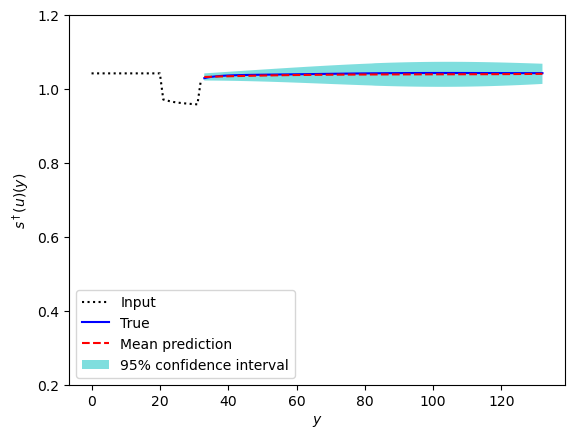

In [7]:
# ===================================
# Trajectory prediction and UQ
# ===================================
print("\n" + "=" * 50)
print("Trajectory prediction and uncertainty quantification")
print("=" * 50)
model.set_train(False)

# Test trajectory prediction
print("Testing trajectory prediction...")

# Select a test sample for trajectory prediction
test_path = f"data/test-data-voltage-m-33-mix.npz"
u, y, s = load_real_data(test_path)


# Predict trajectories
data_index = 1100
u_single = u[data_index]
y_single = y[data_index]
s_true = s[data_index]

print(f"Predicting trajectories at {len(y_single)} time points...")

predict_and_plot(u_single, y_single, s_true, model)

L1: 0.0063 L2: 0.0078


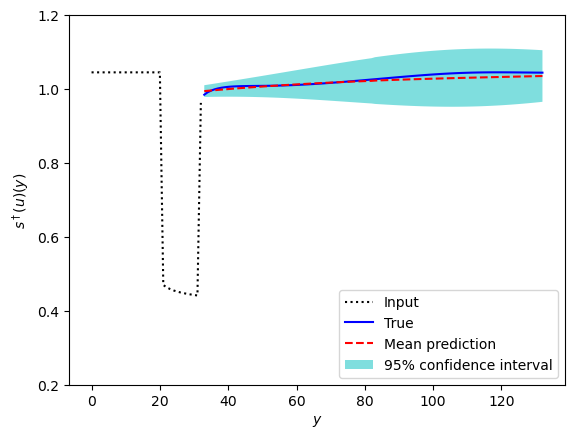

In [8]:
data_index = 560
u_single = u[data_index]
y_single = y[data_index]
s_true = s[data_index]
predict_and_plot(u_single, y_single, s_true, model)

L1: 0.1121 L2: 0.1238


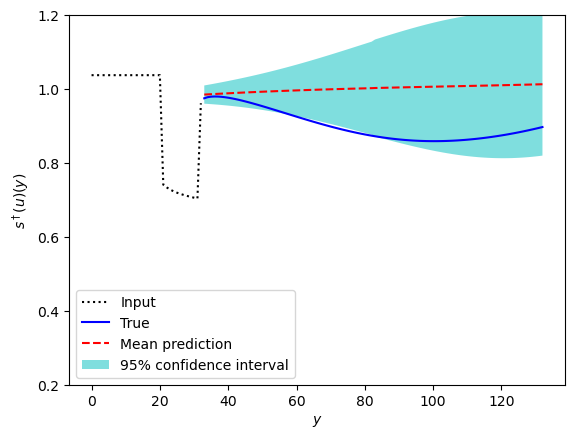

In [9]:
data_index = 803
u_single = u[data_index]
y_single = y[data_index]
s_true = s[data_index]
predict_and_plot(u_single, y_single, s_true, model)

In [40]:
# ===================================
# Save results
# ===================================
print("\n" + "=" * 50)
print("Saving results")
print("=" * 50)

# Save training history
import json
history_path = os.path.join('outputs', 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to: {history_path}")

# Save test results
test_results_path = os.path.join('outputs', 'test_results.json')
with open(test_results_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(f"Test results saved to: {test_results_path}")

# Save model
trainer.save_model('final_model.ckpt')
print("Final model saved to: outputs/final_model.ckpt")

print("\n" + "=" * 50)
print("DeepONet-Grid-UQ MindSpore example completed successfully!")
print("=" * 50)

INFO:src.trainer:Model saved to: outputs/final_model.ckpt



Saving results
Training history saved to: outputs/training_history.json
Test results saved to: outputs/test_results.json
Final model saved to: outputs/final_model.ckpt

DeepONet-Grid-UQ MindSpore example completed successfully!
